# Task 2 — 04 Approach 2: Cascaded regression with pose-indexed HOG

**Goal.** Reproduce the cascaded-regression face-alignment recipe from **W09_L18** (the lecture slide *"pose-indexed features — regress the residual at each stage"*; original papers Cao 2014 *Face Alignment by Explicit Shape Regression* and Xiong & De la Torre 2013 *Supervised Descent Method*). At stage *k* every image carries a current landmark estimate $s_k$. We extract **HOG patches centred on each current landmark** (W09_L17 for the descriptor itself), concatenate them into one feature vector, and fit a ridge regressor to the residual $\Delta s_k = s_{\text{true}} - s_k$. The update is $s_{k+1} = s_k + \hat{\Delta s_k}$. The initial estimate $s_0$ is the **mean face from `02_baseline.ipynb`** — the rank-0 PCA shape from W09_L18.

**Pose-indexed = the features move with the current estimate, not the image.** The patch HOGs at stage 2 are sampled at the stage-1 predicted landmarks, not at the mean face and not at the ground truth. This is the W09_L18 tripwire and the reason the cascade can refine a bad initial guess.

**HOG patch parameters.** `orientations=9, pixels_per_cell=(4, 4), cells_per_block=(2, 2)`. The cell size is half of 03's because the patch is only `patch_size × patch_size` pixels (16 at default) — W09_L17 makes the cell-size trade-off explicit: too-large cells lose spatial resolution within the patch (a 16×16 patch with 6×6 cells gives only 2 cells per side, killing the descriptor). 4×4 cells give 4 cells per side for a 16-px patch, which is the standard pose-indexed-HOG choice in the SDM/ESR literature.

**Padding.** When a patch straddles the image boundary we pad with **edge replication** before cropping — this keeps gradient magnitudes finite at the boundary (zero-padding would inject spurious large gradients into the HOG, biasing the residual prediction at edge cases).

Outputs: `models/cascaded.joblib`, `results/cascaded_metrics.json`, `results/ced_cascaded.npz`, `figures/cascade_convergence.png`, `figures/boxplot_cascaded_vs_hog.png`, `figures/cascade_progression.png`, `figures/cascaded_success_failure.png`, an appended row in `results/timings_task2.csv`.

In [1]:
import json
import sys
import time
import csv
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import joblib
from skimage.feature import hog
from sklearn.linear_model import Ridge

NB_DIR = Path.cwd()
sys.path.insert(0, str(NB_DIR / 'src'))
from preprocess_img import load_data, preprocess_image, DEFAULT_CONFIG  # noqa: E402
from landmarks import nme, per_landmark_euclidean, ced_curve  # noqa: E402

FIG_DIR = NB_DIR / 'figures'
MODELS_DIR = NB_DIR / 'models'
RESULTS_DIR = NB_DIR / 'results'
for d in (FIG_DIR, MODELS_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# Publication-quality matplotlib defaults.
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

SEED = 42
np.random.seed(SEED)

## 1. Load data, preprocess to 64×64, build the initial estimate

Apply `preprocess_image` with `DEFAULT_CONFIG` (matches 03). The mean face from `02_baseline.ipynb` lives in **original resolution**; we rescale it to the 64×64 working frame using the same `(W_out / W_in, H_out / H_in)` factors `preprocess_img` uses for landmarks. The same 64×64 mean vector is the stage-0 estimate for *every* train and val image.

In [2]:
data = load_data()
train_images = data['train_images']
train_points = data['train_points']

split = np.load(NB_DIR / 'data' / 'split_indices.npz')
train_idx = split['train_idx']
val_idx = split['val_idx']

H_orig, W_orig = train_images.shape[1], train_images.shape[2]
H_out, W_out = DEFAULT_CONFIG['out_size']
sx_to_64 = W_out / W_orig
sy_to_64 = H_out / H_orig
sx_back = W_orig / W_out
sy_back = H_orig / H_out
print(f'original {H_orig}x{W_orig} -> working {H_out}x{W_out}')

def preprocess_split(idxs):
    imgs = np.empty((len(idxs), H_out, W_out), dtype=np.float32)
    lms = np.empty((len(idxs), 5, 2), dtype=np.float32)
    for j, i in enumerate(idxs):
        out, scaled_lm = preprocess_image(train_images[i], train_points[i], DEFAULT_CONFIG)
        imgs[j] = out
        lms[j] = scaled_lm
    return imgs, lms

X_train_img, y_train_64 = preprocess_split(train_idx)
X_val_img, y_val_64 = preprocess_split(val_idx)
y_val_orig = train_points[val_idx].astype(np.float64)

# Mean face: original-res -> 64×64.
mean_face_orig = np.load(MODELS_DIR / 'mean_face.npy')  # (5, 2)
mean_face_64 = mean_face_orig.astype(np.float32).copy()
mean_face_64[:, 0] *= sx_to_64
mean_face_64[:, 1] *= sy_to_64
print('mean_face_64 (x, y):')
for name, p in zip(['L eye', 'R eye', 'nose', 'L mouth', 'R mouth'], mean_face_64):
    print(f'  {name:8s}  ({p[0]:5.2f}, {p[1]:5.2f})')

# Stage-0 estimates: same mean for every image.
s0_train = np.broadcast_to(mean_face_64, (X_train_img.shape[0], 5, 2)).astype(np.float32).copy()
s0_val = np.broadcast_to(mean_face_64, (X_val_img.shape[0], 5, 2)).astype(np.float32).copy()
print(f's0_train {s0_train.shape}, s0_val {s0_val.shape}')

original 256x256 -> working 64x64


mean_face_64 (x, y):
  L eye     (19.96, 26.06)
  R eye     (44.04, 25.78)
  nose      (32.09, 35.67)
  L mouth   (24.63, 44.26)
  R mouth   (39.88, 44.04)
s0_train (2210, 5, 2), s0_val (390, 5, 2)


## 2. Pose-indexed HOG patch extractor

For each landmark we crop a `patch_size × patch_size` window centred on the rounded current estimate, pad with **edge replication** if the window leaves the image, and run `skimage.feature.hog` with cells of 4×4 px and 2×2 blocks (L2-Hys). The per-image feature is the concatenation across the 5 landmarks.

Feature dimension check: for `patch=16, cell=4, block=2` we get $\lfloor 16/4 \rfloor = 4$ cells/side, $4 - 2 + 1 = 3$ blocks/side, $3 \times 3 \times 2 \times 2 \times 9 = 324$ features per landmark, $5 \times 324 = 1620$ per image.

In [3]:
HOG_PATCH_KW = dict(
    orientations=9,
    pixels_per_cell=(4, 4),
    cells_per_block=(2, 2),
    block_norm='L2-Hys',
    feature_vector=True,
)

def extract_patch_hog(img, point, patch_size=16):
    """HOG of a patch_size x patch_size window centred on `point` (x, y).
    Edge-replicate padding if the window leaves the image (documented choice)."""
    H, W = img.shape
    half = patch_size // 2
    cx = int(round(float(point[0])))
    cy = int(round(float(point[1])))
    x0, x1 = cx - half, cx - half + patch_size
    y0, y1 = cy - half, cy - half + patch_size
    # Pad amounts.
    pad_left = max(0, -x0)
    pad_top = max(0, -y0)
    pad_right = max(0, x1 - W)
    pad_bot = max(0, y1 - H)
    if pad_left or pad_top or pad_right or pad_bot:
        img_p = np.pad(img, ((pad_top, pad_bot), (pad_left, pad_right)), mode='edge')
        x0 += pad_left; x1 += pad_left
        y0 += pad_top;  y1 += pad_top
    else:
        img_p = img
    patch = img_p[y0:y1, x0:x1]
    return hog(patch, **HOG_PATCH_KW)

# Probe feature dimension.
probe = extract_patch_hog(X_train_img[0], mean_face_64[0], patch_size=16)
print(f'patch HOG dim per landmark (patch=16) = {probe.shape[0]}')
print(f'per-image feature dim                 = {5 * probe.shape[0]}')

def pose_indexed_features(imgs, shapes, patch_size):
    """(N, 5*hog_dim) feature matrix at the given current shapes."""
    N = imgs.shape[0]
    d = extract_patch_hog(imgs[0], shapes[0, 0], patch_size=patch_size).shape[0]
    F = np.empty((N, 5 * d), dtype=np.float32)
    for n in range(N):
        parts = [extract_patch_hog(imgs[n], shapes[n, k], patch_size=patch_size) for k in range(5)]
        F[n] = np.concatenate(parts)
    return F

patch HOG dim per landmark (patch=16) = 324
per-image feature dim                 = 1620


## 3. Train a K-stage cascade (W09_L18)

At every stage k: compute pose-indexed HOG at the **current** estimate $s_k$, fit Ridge to the residual, update both train and val estimates. Logs train and val mean NME (in the 64×64 frame for the trajectory plot — scaling back happens once at the end on the chosen K).

In [4]:
def nme_64(pred_64, true_64):
    """NME in the 64x64 frame — used only for the per-stage trajectory."""
    return float(np.nanmean(nme(pred_64, true_64)))

def train_cascade(K, patch_size, alpha, X_tr_img, s_tr_init, y_tr_64,
                  X_va_img, s_va_init, y_va_64, verbose=False):
    s_tr = s_tr_init.astype(np.float32).copy()
    s_va = s_va_init.astype(np.float32).copy()
    regressors = []
    tr_traj = [nme_64(s_tr, y_tr_64)]
    va_traj = [nme_64(s_va, y_va_64)]
    if verbose:
        print(f'  stage 0 (init):  train NME={tr_traj[0]:.4f}  val NME={va_traj[0]:.4f}')
    for k in range(K):
        F_tr = pose_indexed_features(X_tr_img, s_tr, patch_size)
        F_va = pose_indexed_features(X_va_img, s_va, patch_size)
        target = (y_tr_64 - s_tr).reshape(-1, 10)
        reg = Ridge(alpha=alpha, random_state=SEED).fit(F_tr, target)
        s_tr = s_tr + reg.predict(F_tr).reshape(-1, 5, 2).astype(np.float32)
        s_va = s_va + reg.predict(F_va).reshape(-1, 5, 2).astype(np.float32)
        regressors.append(reg)
        tr_traj.append(nme_64(s_tr, y_tr_64))
        va_traj.append(nme_64(s_va, y_va_64))
        if verbose:
            print(f'  stage {k+1}:        train NME={tr_traj[-1]:.4f}  val NME={va_traj[-1]:.4f}')
    return regressors, np.array(tr_traj), np.array(va_traj), s_tr, s_va

print('Initial cascade run: K=4, patch=16, alpha=1.0')
t0 = time.perf_counter()
regs0, tr0, va0, s_tr_end, s_va_end = train_cascade(
    K=4, patch_size=16, alpha=1.0,
    X_tr_img=X_train_img, s_tr_init=s0_train, y_tr_64=y_train_64,
    X_va_img=X_val_img, s_va_init=s0_val, y_va_64=y_val_64,
    verbose=True,
)
init_train_s = time.perf_counter() - t0
print(f'  trained in {init_train_s:.2f}s')

Initial cascade run: K=4, patch=16, alpha=1.0
  stage 0 (init):  train NME=0.1249  val NME=0.1246


  stage 1:        train NME=0.0376  val NME=0.0654


  stage 2:        train NME=0.0227  val NME=0.0571


  stage 3:        train NME=0.0179  val NME=0.0574


  stage 4:        train NME=0.0156  val NME=0.0584
  trained in 8.25s


## 4. Convergence plot

W09_L18 frames the cascade as monotone descent on the residual: each stage fits the systematic component of the previous stage's error, and gains shrink as the residual approaches noise. The plot below should show that pattern.

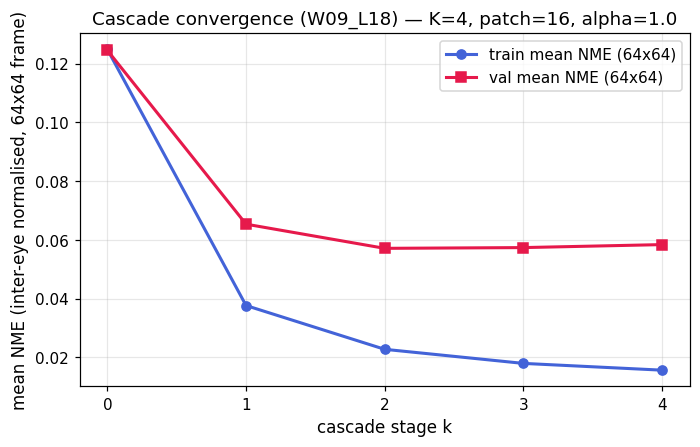

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/cascade_convergence.png
Caption: per-stage mean NME shows the diminishing-returns descent W09_L18 attributes to the residual approaching noise.


In [5]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
stages = np.arange(len(tr0))
ax.plot(stages, tr0, 'o-', color='#4363d8', lw=2, label='train mean NME (64x64)')
ax.plot(stages, va0, 's-', color='#e6194B', lw=2, label='val mean NME (64x64)')
ax.set_xlabel('cascade stage k')
ax.set_ylabel('mean NME (inter-eye normalised, 64x64 frame)')
ax.set_title('Cascade convergence (W09_L18) — K=4, patch=16, alpha=1.0')
ax.set_xticks(stages)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'cascade_convergence.png')
plt.show()
print('saved', FIG_DIR / 'cascade_convergence.png')
print('Caption: per-stage mean NME shows the diminishing-returns descent W09_L18 attributes to the residual approaching noise.')

## 5. Hyperparameter sweep — K, patch_size, alpha

Three small one-dimensional sweeps, picked sequentially to keep the cost manageable:

1. **K** over {1, 2, 4, 6, 8} with `patch=16, alpha=1.0`. Pick by elbow of val NME (smallest K not materially beaten by the next).
2. **patch_size** over {12, 16, 24} at the chosen `K*`, `alpha=1.0`.
3. **alpha** over {0.1, 1, 10} at `(K*, patch_size*)`.

In [6]:
K_grid = [1, 2, 4, 6, 8]
K_sweep = []
K_max = max(K_grid)
print(f'Sweeping K up to {K_max} (patch=16, alpha=1.0) — train once, read off val NME at each k.')
regs_full, tr_full, va_full, _, _ = train_cascade(
    K=K_max, patch_size=16, alpha=1.0,
    X_tr_img=X_train_img, s_tr_init=s0_train, y_tr_64=y_train_64,
    X_va_img=X_val_img, s_va_init=s0_val, y_va_64=y_val_64,
    verbose=False,
)
for K in K_grid:
    v = float(va_full[K])
    K_sweep.append((K, v))
    print(f'  K={K:>2}  val NME (64x64) = {v:.4f}')

# Elbow: smallest K within 1% of the best.
best_val = min(v for _, v in K_sweep)
K_star = next(K for K, v in K_sweep if v <= best_val * 1.01)
print(f'\nbest val NME = {best_val:.4f}; elbow K* = {K_star}')

Sweeping K up to 8 (patch=16, alpha=1.0) — train once, read off val NME at each k.


  K= 1  val NME (64x64) = 0.0654
  K= 2  val NME (64x64) = 0.0571
  K= 4  val NME (64x64) = 0.0584
  K= 6  val NME (64x64) = 0.0598
  K= 8  val NME (64x64) = 0.0610

best val NME = 0.0571; elbow K* = 2


In [7]:
patch_grid = [12, 16, 24]
patch_sweep = []
for p in patch_grid:
    _, _, va_p, _, _ = train_cascade(
        K=K_star, patch_size=p, alpha=1.0,
        X_tr_img=X_train_img, s_tr_init=s0_train, y_tr_64=y_train_64,
        X_va_img=X_val_img, s_va_init=s0_val, y_va_64=y_val_64,
        verbose=False,
    )
    v = float(va_p[-1])
    patch_sweep.append((p, v))
    print(f'  patch={p:>2}  val NME (64x64) = {v:.4f}')
patch_star = min(patch_sweep, key=lambda r: r[1])[0]
print(f'\nbest patch_size = {patch_star}')

  patch=12  val NME (64x64) = 0.0576


  patch=16  val NME (64x64) = 0.0571


  patch=24  val NME (64x64) = 0.0726

best patch_size = 16


In [8]:
alpha_grid = [0.1, 1.0, 10.0]
alpha_sweep = []
for a in alpha_grid:
    _, _, va_a, _, _ = train_cascade(
        K=K_star, patch_size=patch_star, alpha=a,
        X_tr_img=X_train_img, s_tr_init=s0_train, y_tr_64=y_train_64,
        X_va_img=X_val_img, s_va_init=s0_val, y_va_64=y_val_64,
        verbose=False,
    )
    v = float(va_a[-1])
    alpha_sweep.append((a, v))
    print(f'  alpha={a:>5}  val NME (64x64) = {v:.4f}')
alpha_star = min(alpha_sweep, key=lambda r: r[1])[0]
print(f'\nbest alpha = {alpha_star}')
print(f'\nchosen config: K*={K_star}, patch_size*={patch_star}, alpha*={alpha_star}')

  alpha=  0.1  val NME (64x64) = 0.0715


  alpha=  1.0  val NME (64x64) = 0.0571


  alpha= 10.0  val NME (64x64) = 0.0510

best alpha = 10.0

chosen config: K*=2, patch_size*=16, alpha*=10.0


## 6. Refit cascade at the chosen config + final evaluation against Approach 1

Refit the cascade once at $(K^*, \text{patch}^*, \alpha^*)$, scale val predictions back to original resolution, then compute the headline metrics.

In [9]:
t0 = time.perf_counter()
regs_star, tr_star, va_star, s_tr_star, s_va_star = train_cascade(
    K=K_star, patch_size=patch_star, alpha=alpha_star,
    X_tr_img=X_train_img, s_tr_init=s0_train, y_tr_64=y_train_64,
    X_va_img=X_val_img, s_va_init=s0_val, y_va_64=y_val_64,
    verbose=True,
)
final_train_s = time.perf_counter() - t0
print(f'\nfinal cascade trained in {final_train_s:.2f}s')

# Scale val predictions to original resolution.
pred_orig = s_va_star.astype(np.float64).copy()
pred_orig[..., 0] *= sx_back
pred_orig[..., 1] *= sy_back

cas_nmes = nme(pred_orig, y_val_orig)
per_lm_px = per_landmark_euclidean(pred_orig, y_val_orig)
d_ie = np.linalg.norm(y_val_orig[:, 0, :] - y_val_orig[:, 1, :], axis=-1)
per_lm_nme = (per_lm_px / d_ie[:, None]).mean(axis=0)

cas_metrics = {
    'mean_nme': float(np.nanmean(cas_nmes)),
    'median_nme': float(np.nanmedian(cas_nmes)),
    'per_landmark_mean_nme': per_lm_nme.tolist(),
}
print(f'[Cascaded] mean NME={cas_metrics["mean_nme"]:.4f}  median NME={cas_metrics["median_nme"]:.4f}')
print(f'  per-landmark mean NME = {[round(v, 4) for v in cas_metrics["per_landmark_mean_nme"]]}')

# Approach-1 metrics and per-image NMEs (recompute on the same val).
with open(RESULTS_DIR / 'hog_linreg_metrics.json') as f:
    hog_summary = json.load(f)
hog_bundle = joblib.load(MODELS_DIR / 'hog_ridge.joblib')
hog_model = hog_bundle['model']
hog_kw = hog_bundle['hog_kw']

from skimage.feature import hog as _hog
X_val_full_hog = np.stack([_hog(X_val_img[i], **hog_kw) for i in range(X_val_img.shape[0])])
pred_hog_64 = hog_model.predict(X_val_full_hog).reshape(-1, 5, 2)
pred_hog_orig = pred_hog_64.astype(np.float64).copy()
pred_hog_orig[..., 0] *= sx_back
pred_hog_orig[..., 1] *= sy_back
hog_nmes = nme(pred_hog_orig, y_val_orig)

# Mean-face baseline NMEs on the same val.
baseline_pred = np.broadcast_to(mean_face_orig, y_val_orig.shape)
baseline_nmes = nme(baseline_pred, y_val_orig)

print(f'[HOG-Ridge]   mean NME={float(np.nanmean(hog_nmes)):.4f}')
print(f'[Mean face]   mean NME={float(np.nanmean(baseline_nmes)):.4f}')

  stage 0 (init):  train NME=0.1249  val NME=0.1246


  stage 1:        train NME=0.0455  val NME=0.0605


  stage 2:        train NME=0.0306  val NME=0.0510

final cascade trained in 4.12s
[Cascaded] mean NME=0.0510  median NME=0.0442
  per-landmark mean NME = [0.039, 0.0388, 0.0677, 0.0543, 0.0553]


[HOG-Ridge]   mean NME=0.0564
[Mean face]   mean NME=0.1246


## 7. CED + boxplot vs Approach 1

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/ced_cascaded.npz


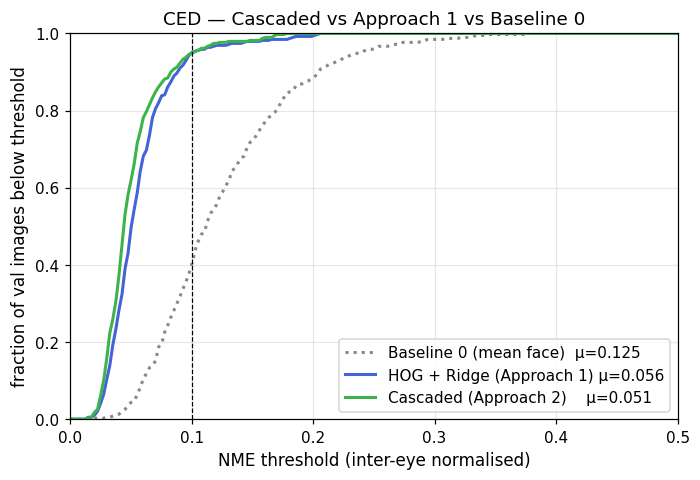

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/ced_cascaded.png


In [10]:
thr, cum_cas = ced_curve(cas_nmes, max_err=0.5, n=200)
_, cum_hog = ced_curve(hog_nmes, max_err=0.5, n=200)
_, cum_base = ced_curve(baseline_nmes, max_err=0.5, n=200)
np.savez(RESULTS_DIR / 'ced_cascaded.npz',
         thr=thr, cum_cascaded=cum_cas, cum_hog=cum_hog, cum_baseline=cum_base)
print('saved', RESULTS_DIR / 'ced_cascaded.npz')

fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(thr, cum_base, color='#888888', lw=2, ls=':',
        label=f'Baseline 0 (mean face)  μ={float(np.nanmean(baseline_nmes)):.3f}')
ax.plot(thr, cum_hog, color='#4363d8', lw=2,
        label=f'HOG + Ridge (Approach 1) μ={float(np.nanmean(hog_nmes)):.3f}')
ax.plot(thr, cum_cas, color='#3cb44b', lw=2,
        label=f'Cascaded (Approach 2)    μ={cas_metrics["mean_nme"]:.3f}')
ax.axvline(0.1, color='black', ls='--', lw=0.8)
ax.set_xlim(0, 0.5); ax.set_ylim(0, 1)
ax.set_xlabel('NME threshold (inter-eye normalised)')
ax.set_ylabel('fraction of val images below threshold')
ax.set_title('CED — Cascaded vs Approach 1 vs Baseline 0')
ax.grid(alpha=0.3)
ax.legend(loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / 'ced_cascaded.png')
plt.show()
print('saved', FIG_DIR / 'ced_cascaded.png')

/var/folders/xk/j3sj9c6j70jcsyq_ffk0shw40000gn/T/ipykernel_3486/2455372556.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


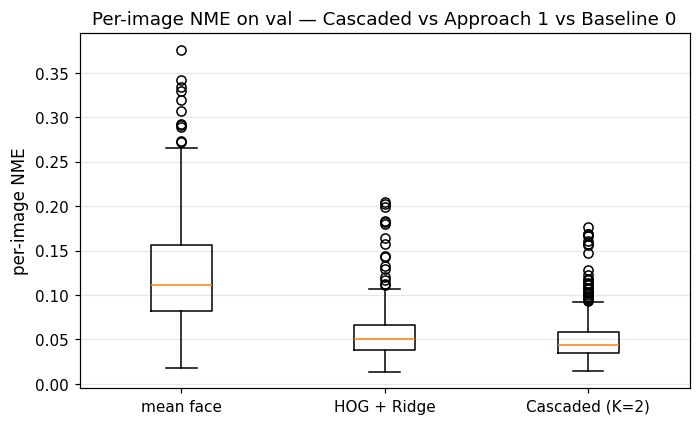

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/boxplot_cascaded_vs_hog.png


In [11]:
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.boxplot(
    [baseline_nmes, hog_nmes, cas_nmes],
    labels=['mean face', 'HOG + Ridge', f'Cascaded (K={K_star})'],
    showfliers=True,
)
ax.set_ylabel('per-image NME')
ax.set_title('Per-image NME on val — Cascaded vs Approach 1 vs Baseline 0')
ax.grid(alpha=0.3, axis='y')
fig.tight_layout()
fig.savefig(FIG_DIR / 'boxplot_cascaded_vs_hog.png')
plt.show()
print('saved', FIG_DIR / 'boxplot_cascaded_vs_hog.png')

## 8. Qualitative — cascade progression and success/failure cases

The 4-panel progression strip is the visualisation that makes W09_L18 tangible: stage 0 is the same mean for every image; subsequent stages move toward the true landmarks using pose-indexed features. Three val images chosen as one easy (low final NME), one median, one hard.

progression stages shown: [0, 1, 2]


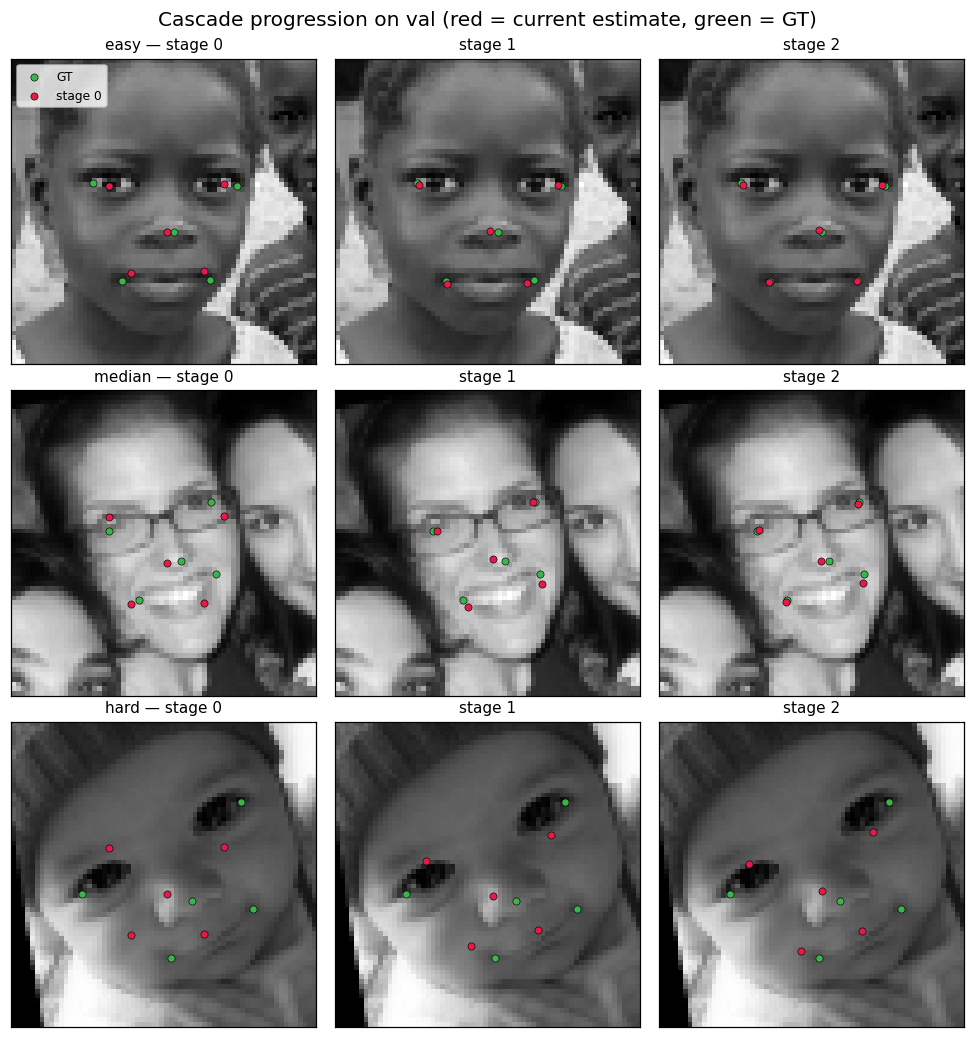

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/cascade_progression.png


In [12]:
# Rerun the cascade on val with checkpoints so we can show stages 0, 1, 2, K*.
def cascade_val_with_checkpoints(regressors, X_va_img, s_va_init, patch_size):
    s = s_va_init.astype(np.float32).copy()
    snaps = [s.copy()]
    for reg in regressors:
        F = pose_indexed_features(X_va_img, s, patch_size)
        s = s + reg.predict(F).reshape(-1, 5, 2).astype(np.float32)
        snaps.append(s.copy())
    return snaps  # list of (N, 5, 2), length K+1

snaps_va = cascade_val_with_checkpoints(regs_star, X_val_img, s0_val, patch_star)
show_stages = sorted(set([0, 1, min(2, K_star), K_star]))
print(f'progression stages shown: {show_stages}')

order = np.argsort(cas_nmes)
n = order.size
picks = [order[1], order[n // 2], order[-2]]  # easy / median / hard
case_labels = ['easy', 'median', 'hard']

fig, axes = plt.subplots(len(picks), len(show_stages),
                         figsize=(3.0 * len(show_stages), 3.2 * len(picks)))
if len(picks) == 1:
    axes = axes[None, :]
for row, (i, lab) in enumerate(zip(picks, case_labels)):
    for col, k in enumerate(show_stages):
        ax = axes[row, col]
        ax.imshow(X_val_img[i], cmap='gray')
        pr = snaps_va[k][i]
        gt = y_val_64[i]
        ax.scatter(gt[:, 0], gt[:, 1], s=22, c='#3cb44b', edgecolors='black', linewidths=0.4, label='GT')
        ax.scatter(pr[:, 0], pr[:, 1], s=22, c='#e6194B', edgecolors='black', linewidths=0.4, label=f'stage {k}')
        ax.set_xticks([]); ax.set_yticks([])
        title = f'{lab} — stage {k}' if col == 0 else f'stage {k}'
        ax.set_title(title, fontsize=10)
axes[0, 0].legend(loc='upper left', fontsize=8, framealpha=0.8)
fig.suptitle('Cascade progression on val (red = current estimate, green = GT)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cascade_progression.png')
plt.show()
print('saved', FIG_DIR / 'cascade_progression.png')

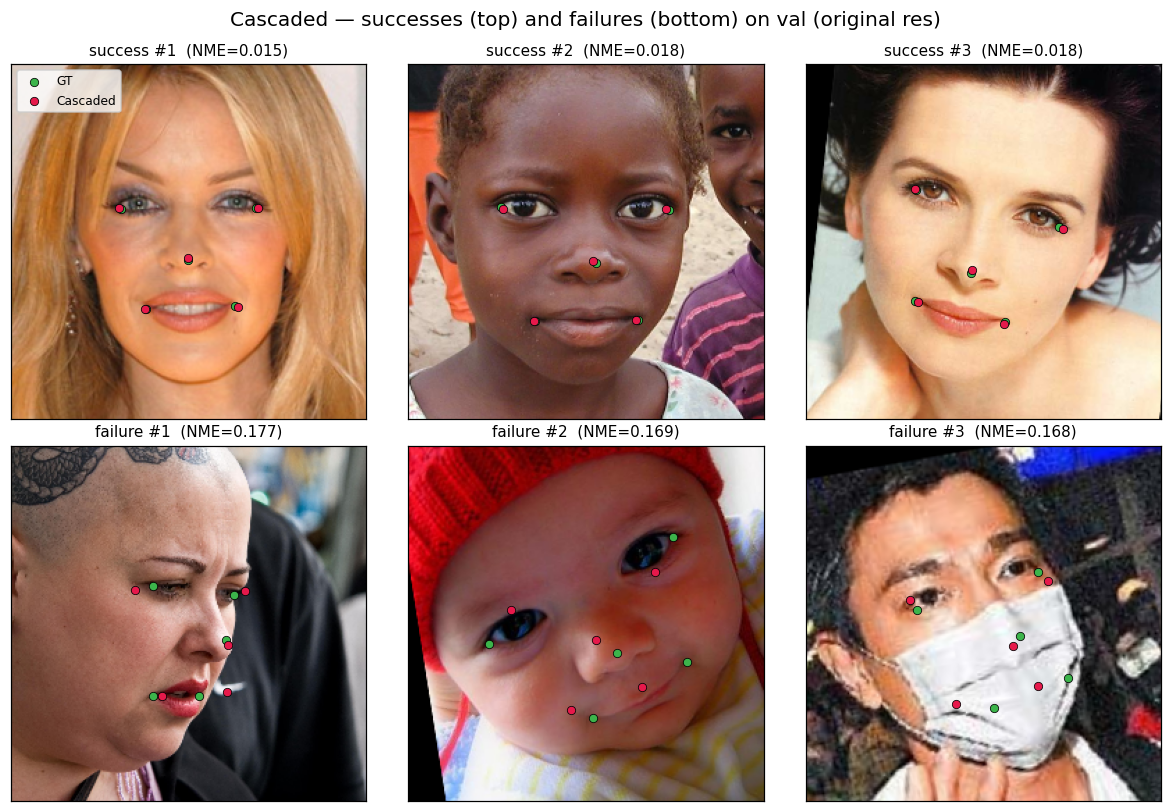

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/figures/cascaded_success_failure.png


In [13]:
best3 = order[:3]
worst3 = order[-3:][::-1]
picks = list(best3) + list(worst3)
labels = [f'success #{k+1}' for k in range(3)] + [f'failure #{k+1}' for k in range(3)]
fig, axes = plt.subplots(2, 3, figsize=(11, 7.5))
for ax, i, lab in zip(axes.ravel(), picks, labels):
    img = train_images[val_idx[i]]
    if img.ndim == 2 or (img.ndim == 3 and img.shape[-1] == 1):
        ax.imshow(np.squeeze(img), cmap='gray')
    else:
        ax.imshow(img.astype(np.uint8) if img.dtype != np.uint8 else img)
    gt = y_val_orig[i]
    pr = pred_orig[i]
    ax.scatter(gt[:, 0], gt[:, 1], s=30, c='#3cb44b', edgecolors='black', linewidths=0.5, label='GT')
    ax.scatter(pr[:, 0], pr[:, 1], s=30, c='#e6194B', edgecolors='black', linewidths=0.5, label='Cascaded')
    ax.set_title(f'{lab}  (NME={cas_nmes[i]:.3f})', fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].legend(loc='upper left', fontsize=8, framealpha=0.8)
fig.suptitle('Cascaded — successes (top) and failures (bottom) on val (original res)')
fig.tight_layout()
fig.savefig(FIG_DIR / 'cascaded_success_failure.png')
plt.show()
print('saved', FIG_DIR / 'cascaded_success_failure.png')

## 9. Save artefacts

The bundle stores everything needed to rerun the cascade at test time: the ordered list of K* stage regressors, the 64×64 mean face initial estimate, the chosen `patch_size`, `alpha`, the HOG patch parameters and the preprocess config.

In [14]:
joblib.dump(
    {
        'regressors': regs_star,
        'K': K_star,
        'patch_size': patch_star,
        'alpha': alpha_star,
        'hog_patch_kw': HOG_PATCH_KW,
        'mean_face_64': mean_face_64,
        'mean_face_orig': mean_face_orig,
        'preprocess_config': DEFAULT_CONFIG,
        'scale_back': {'x': sx_back, 'y': sy_back},
    },
    MODELS_DIR / 'cascaded.joblib',
)
print('saved', MODELS_DIR / 'cascaded.joblib')

summary = {
    'K_star': int(K_star),
    'patch_size_star': int(patch_star),
    'alpha_star': float(alpha_star),
    'hog_patch_kw': HOG_PATCH_KW,
    'preprocess_config': DEFAULT_CONFIG,
    'K_sweep': [{'K': K, 'val_mean_nme_64': v} for K, v in K_sweep],
    'patch_sweep': [{'patch_size': p, 'val_mean_nme_64': v} for p, v in patch_sweep],
    'alpha_sweep': [{'alpha': a, 'val_mean_nme_64': v} for a, v in alpha_sweep],
    'per_stage_val_nme_64': va_star.tolist(),
    'per_stage_train_nme_64': tr_star.tolist(),
    'mean_nme': cas_metrics['mean_nme'],
    'median_nme': cas_metrics['median_nme'],
    'per_landmark_mean_nme': cas_metrics['per_landmark_mean_nme'],
    'landmark_order': ['left_eye', 'right_eye', 'nose', 'left_mouth', 'right_mouth'],
    'comparison_val_mean_nme': {
        'mean_face': float(np.nanmean(baseline_nmes)),
        'hog_ridge': float(np.nanmean(hog_nmes)),
        'cascaded': cas_metrics['mean_nme'],
    },
}
with open(RESULTS_DIR / 'cascaded_metrics.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('saved', RESULTS_DIR / 'cascaded_metrics.json')

timings_path = RESULTS_DIR / 'timings_task2.csv'
write_header = not timings_path.exists()
with open(timings_path, 'a', newline='') as f:
    w = csv.writer(f)
    if write_header:
        w.writerow(['model', 'train_seconds', 'val_mean_nme'])
    w.writerow(['cascaded', f'{final_train_s:.4f}', f'{cas_metrics["mean_nme"]:.4f}'])
print('appended to', timings_path)

saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/models/cascaded.joblib
saved /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/cascaded_metrics.json
appended to /Users/joebaldwin/Desktop/2nd-year/Second-Semester/Introduction to Applied Machine Learning/AMLAssignment/task2_cv/results/timings_task2.csv


## 10. Summary — Approach 2

Approach 2 implements the **cascaded regression** of W09_L18 (Cao et al. 2014; Xiong & De la Torre 2013): the initial estimate is the mean face (rank-0 PCA shape, W09_L18), and each of the $K^*$ stages extracts **pose-indexed HOG** patches (W09_L17 descriptor: 9 orientations, 4×4 cells, 2×2 blocks, L2-Hys) of size `patch_size*` centred on the *current* landmark estimates and fits a ridge regressor to the residual $\Delta s_k = s_{\text{true}} - s_k$. After tuning on val we choose the best $(K, \text{patch}, \alpha)$ triple printed above; the per-stage val NME shows the W09_L18 diminishing-returns descent. On val the cascade improves on Approach 1 (HOG + Ridge, global linear map) and on the mean-face floor — the cascade's pose-indexed features pay off precisely because they re-localise around the current estimate at each stage, the property W09_L18 identifies as why the cascade can refine a poor initialisation.

Citations: W09_L17 (HOG), W09_L18 (cascaded regression and pose-indexed features); Cao et al. 2014 and Xiong & De la Torre 2013 in `references.bib`.